In [24]:
import numpy as np
import matplotlib.pyplot as plt

m = 1.67e-27
q = 1.6e-19
V = 1000
a = 0.1
d = 1
dt = 1e-9

t_values = [0]
x_values = [0]

x_one = 1/2 * (q * V)/(m*a) * dt**2

t_values.append(dt)
x_values.append(x_one)


In [22]:
while x_values[-1] < d:
    F = q*V/a if x_values[-1] <= a else 0
    x_next = 2 * x_values[-1] - x_values[-2] + (F / m) * dt**2
    x_values.append(x_next)
    t_values.append(t_values[-1] + dt)

t_arr = np.array(t_values)
x_arr = np.array(x_values)

indices_past_a = np.where(x_arr >= a)[0]
a_index = indices_past_a[0]
simulated_t_a = t_arr[a_index]

exact_t_a = np.sqrt(2*m*a**2/(q*V))

t_drift = t_arr[-1] - simulated_t_a
m_to_q = 2 * V * t_drift**2 / (d - a)**2

print(f'Exact t_a: {exact_t_a} \nSimulated t_a: {simulated_t_a}')
print(f'\nExact mass to charge ratio: {m/q} \nSimulated mass to charge ratio: {m_to_q}')

Exact t_a: 4.568916720624267e-07 
Simulated t_a: 4.5700000000000416e-07

Exact mass to charge ratio: 1.0437500000000002e-08 
Simulated mass to charge ratio: 1.0457688888889936e-08


### Explanation of the mass/charge mismatch

The small difference between the exact and simulated mass-to-charge ratio (about 0.2%) is a due to a numerical error caused by the time discretization (`dt = 1e-9` s). 

The particle actually crosses the boundary `x = a` somewhere between two time steps. Because the algorithm only calculates position at exact 1-nanosecond intervals, it registers the crossing slightly late. This tiny error in tracking the exact moment it leaves the electric field propagates into the drift time calculation, resulting in the mismatch in the final ratio. 

Decreasing the time step would make the simulated ratio more accurate, but it would require more computational power.

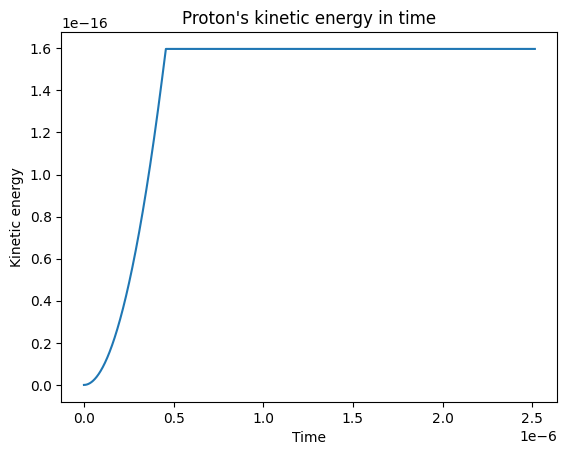

4.5700000000000416e-07


In [ ]:
v_arr = np.gradient(x_arr, dt)
ke_arr = 0.5 * m * v_arr**2

plt.plot(t_arr, ke_arr)

plt.title("Proton's kinetic energy in time")
plt.xlabel('Time')
plt.ylabel('Kinetic energy')

plt.show()